# 🔢 Notebook 2 — Index Construction & Master Dataset

---

## What we did

We took the raw data from Notebook 1 and built a composite index — the **Climate-Labor Vulnerability Index (CLVI)** — that combines multiple dimensions of vulnerability into a single comparable score for every country.

We also calculated a **protection gap** score showing how much each country's vulnerability exceeds its social protection provision.

---

## How the CLVI is built

The CLVI combines two sub-scores, weighted equally (50/50):

**Physical Exposure Score** — built from:
- Climate hazard exposure (WRI)
- Lack of coping capacity (WRI)
- Lack of adaptation capacity (WRI)
- Susceptibility to harm (WRI)

**Socioeconomic Vulnerability Score** — built from:
- Poverty ratio (WDI)
- Gini inequality coefficient (WIID)
- Palma ratio — income of top 10% vs bottom 40% (WIID)
- Inverted GDP per capita — lower income = higher vulnerability

All scores are normalised to a **0 to 1 scale** so they are directly comparable across countries.

---

## How the protection gap is calculated
```
Protection Gap = CLVI score − SP coverage score (normalised)
```

A **positive** gap means the country is more vulnerable than it is protected — the higher the number, the more urgent the need.

A **negative** gap means protection exceeds vulnerability — typical of wealthy European countries.

---

## Sensitivity analysis

We tested whether the 50/50 weighting assumption matters by running three alternative weightings:

| Weighting | Physical / Socioeconomic | Correlation with base CLVI |
|-----------|--------------------------|---------------------------|
| Base case | 50% / 50% | — |
| Alternative 1 | 60% / 40% | r ≈ 0.99 |
| Alternative 2 | 40% / 60% | r ≈ 0.99 |
| Alternative 3 | 70% / 30% | r ≈ 0.98 |

> **The country rankings are stable regardless of weighting.** The index is robust — our conclusions do not depend on the 50/50 assumption.

---

## Key findings from index construction

- **Top CLVI score:** Central African Republic (0.748) — the most vulnerable country in the dataset
- **Lowest CLVI score:** Monaco (0.074) — statistical outlier, tiny wealthy microstate
- **Largest protection gap:** Mozambique (0.635) — highest measured gap in the dataset
- **Zero SP coverage:** Somalia — the only country recording zero formal social protection

---

## The quadrant picture

Of the **113 countries with SP coverage data:**

| Zone | Countries | % |
|------|-----------|---|
| 🔴 Red Zone — high vulnerability, low protection | 21 | 19% |
| 🟠 Tension Zone — high vulnerability, some protection | 4 | 4% |
| 🟡 Gap Zone — lower vulnerability, still underprotected | 40 | 35% |
| 🟢 Safe Zone — low vulnerability, high protection | 48 | 42% |

> **84% of countries with CLVI above 0.5 have inadequate social protection.** This is Hypothesis 1 confirmed in a single number.

---

## Important caveat

The **79 countries with no SP data** could not be placed in any quadrant. Their mean CLVI (0.309) is lower than visible countries (0.373) on average — but the most extreme cases like Central African Republic and DRC are invisible precisely because state capacity to collect and report data has collapsed. The true Red Zone is almost certainly larger than 21 countries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import spearmanr, ttest_ind
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = (12, 6)

# Load the saved master
master = pd.read_csv('outputs/master.csv')

print(f"✓ Master loaded: {master.shape}")
print(f"✓ Countries: {master['iso3'].nunique()}")
print(f"✓ Columns: {list(master.columns)}")

✓ Master loaded: (192, 30)
✓ Countries: 192
✓ Columns: ['iso3', 'country', 'gain_score', 'vulnerability', 'wri_score', 'exposure', 'susceptibility', 'lack_coping', 'lack_adaptation', 'sp_coverage_rate', 'sp_year', 'gdp_per_capita', 'poverty_ratio', 'unemployment_rate', 'life_expectancy', 'health_exp_gdp', 'gini', 'bottom40_share', 'bottom20_share', 'top20_share', 'top10_share', 'palma_ratio', 'income_group', 'region_un', 'region_wb', 'mean_income_usd', 'adaptive_sp_score', 'has_trigger', 'has_registry', 'log_gdp']


In [2]:
#Cell 2 — Index Construction

scaler = MinMaxScaler()

# ── 1. Physical Climate Exposure Score ───────────────────────────────────────
exposure_vars = ['exposure', 'lack_coping', 'lack_adaptation', 'susceptibility']
master['physical_exposure'] = scaler.fit_transform(
    master[exposure_vars].fillna(master[exposure_vars].median())
).mean(axis=1)

print(f"Physical exposure: {master['physical_exposure'].min():.3f} - {master['physical_exposure'].max():.3f}")

# ── 2. Socioeconomic Vulnerability ───────────────────────────────────────────
master['gdp_inverted'] = 1 - scaler.fit_transform(
    master[['gdp_per_capita']].fillna(master['gdp_per_capita'].median())
).flatten()

socio_vars = ['poverty_ratio', 'gini', 'palma_ratio']
available_socio = [v for v in socio_vars if master[v].notna().sum() > 20]
socio_scaled = scaler.fit_transform(
    master[available_socio].fillna(master[available_socio].median())
)
master['socio_vulnerability'] = np.column_stack(
    [socio_scaled, master['gdp_inverted'].values]
).mean(axis=1)

print(f"Socio vulnerability: {master['socio_vulnerability'].min():.3f} - {master['socio_vulnerability'].max():.3f}")

# ── 3. Composite CLVI ────────────────────────────────────────────────────────
master['CLVI'] = (master['physical_exposure'] * 0.5 +
                  master['socio_vulnerability'] * 0.5)
print(f"CLVI: {master['CLVI'].min():.3f} - {master['CLVI'].max():.3f}")

# ── 4. SP Score ───────────────────────────────────────────────────────────────
master['sp_score'] = scaler.fit_transform(
    master[['sp_coverage_rate']].fillna(master['sp_coverage_rate'].median())
).flatten()
print(f"SP score: {master['sp_score'].min():.3f} - {master['sp_score'].max():.3f}")

# ── 5. Gap Score ──────────────────────────────────────────────────────────────
master['protection_gap'] = master['CLVI'] - master['sp_score']

# ── 6. Sensitivity Analysis ───────────────────────────────────────────────────
print("\nSensitivity analysis:")
for w1, w2 in [(0.6, 0.4), (0.4, 0.6), (0.7, 0.3)]:
    col = f'CLVI_{w1}_{w2}'
    master[col] = (master['physical_exposure'] * w1 +
                   master['socio_vulnerability'] * w2)
    valid = master[['CLVI', col]].dropna()
    r, p = spearmanr(valid['CLVI'], valid[col])
    print(f"  Weights ({w1}/{w2}): r={r:.3f}, p={p:.4f}")

# ── 7. Red Zone Preview ───────────────────────────────────────────────────────
print("\nTop 15 Red Zone Countries (highest protection gap):")
cols = ['country','CLVI','sp_score','protection_gap',
        'sp_coverage_rate','gdp_per_capita','region_un']
print(master[master['sp_coverage_rate'].notna()]
      .nlargest(15, 'protection_gap')[cols]
      .round(3).to_string(index=False))

master.to_csv('outputs/master_indexed.csv', index=False)
print("\n✓ Saved to outputs/master_indexed.csv")

Physical exposure: 0.004 - 0.754
Socio vulnerability: 0.129 - 0.836
CLVI: 0.074 - 0.748
SP score: 0.000 - 1.000

Sensitivity analysis:
  Weights (0.6/0.4): r=0.995, p=0.0000
  Weights (0.4/0.6): r=0.995, p=0.0000
  Weights (0.7/0.3): r=0.981, p=0.0000

Top 15 Red Zone Countries (highest protection gap):
         country  CLVI  sp_score  protection_gap  sp_coverage_rate  gdp_per_capita region_un
      Mozambique 0.695     0.060           0.635               6.0         656.777    Africa
         Somalia 0.596     0.000           0.596               0.0         629.539    Africa
            Chad 0.616     0.025           0.591               2.5         961.560    Africa
           Haiti 0.608     0.066           0.542               6.6        2142.623  Americas
           Yemen 0.567     0.070           0.497               7.0         633.887      Asia
          Angola 0.570     0.087           0.483               8.7        2665.874    Africa
        Ethiopia 0.547     0.074           0

In [3]:
#Cell 3 — Hypothesis Testing
print("=" * 55)
print("H1 — Geographic Mismatch")
print("Higher vulnerability → lower SP coverage?")
print("=" * 55)
h1 = master[['CLVI','sp_coverage_rate','log_gdp']].dropna()
r, p = spearmanr(h1['CLVI'], h1['sp_coverage_rate'])
print(f"Spearman r: {r:.3f}, p={p:.4f}")
print("→", "✓ Supported" if r < 0 and p < 0.05 else "✗ Not supported")

X = sm.add_constant(h1[['CLVI','log_gdp']])
model = sm.OLS(h1['sp_coverage_rate'], X).fit(cov_type='HC3')
print(f"\nOLS controlling for log GDP:")
print(f"  CLVI coef: {model.params['CLVI']:.3f} (p={model.pvalues['CLVI']:.4f})")
print(f"  R²: {model.rsquared:.3f}")

print("\n" + "=" * 55)
print("H2 — Inequality Compounds Vulnerability")
print("Higher gini → lower SP coverage?")
print("=" * 55)
h2 = master[['gini','sp_coverage_rate','log_gdp']].dropna()
r2, p2 = spearmanr(h2['gini'], h2['sp_coverage_rate'])
print(f"Spearman r: {r2:.3f}, p={p2:.4f}")
print("→", "✓ Supported" if r2 < 0 and p2 < 0.05 else "✗ Not supported")

print("\n" + "=" * 55)
print("H3 — Income Group Gap")
print("Low-income countries have lower SP coverage?")
print("=" * 55)
print(master.groupby('income_group')['sp_coverage_rate']
      .agg(['mean','median','count']).round(1))

low  = master[master['income_group'] == 'Low income']['sp_coverage_rate'].dropna()
high = master[master['income_group'] == 'High income']['sp_coverage_rate'].dropna()
if len(low) > 3 and len(high) > 3:
    t, p3 = ttest_ind(low, high)
    print(f"\nT-test: low ({low.mean():.1f}%) vs high ({high.mean():.1f}%) income")
    print(f"t={t:.3f}, p={p3:.4f}")
    print("→", "✓ Supported" if p3 < 0.05 else "✗ Not supported")

print("\n" + "=" * 55)
print("H4 — State Capacity as Financing Proxy")
print("Health expenditure % GDP by income group")
print("=" * 55)
print(master.groupby('income_group')['health_exp_gdp']
      .agg(['mean','median','count']).round(2))

print("\n" + "=" * 55)
print("H5 — Data Invisibility")
print("More vulnerable countries have less complete data?")
print("=" * 55)
master['data_completeness'] = master.notnull().mean(axis=1)
h5 = master[['CLVI','data_completeness']].dropna()
r5, p5 = spearmanr(h5['CLVI'], h5['data_completeness'])
print(f"Spearman r: {r5:.3f}, p={p5:.4f}")
print("→", "✓ Supported (Said hypothesis)" if r5 < 0 and p5 < 0.05
      else "✗ Not supported")
print(f"\nData completeness by region:")
print(master.groupby('region_un')['data_completeness']
      .mean().sort_values().round(3))

H1 — Geographic Mismatch
Higher vulnerability → lower SP coverage?
Spearman r: -0.743, p=0.0000
→ ✓ Supported

OLS controlling for log GDP:
  CLVI coef: -17.754 (p=0.3258)
  R²: 0.786

H2 — Inequality Compounds Vulnerability
Higher gini → lower SP coverage?
Spearman r: -0.416, p=0.0000
→ ✓ Supported

H3 — Income Group Gap
Low-income countries have lower SP coverage?
                     mean  median  count
income_group                            
High income          90.6    95.6     27
Low income           11.8     7.7     21
Lower middle income  30.8    22.8     32
Upper middle income  52.0    53.2     32

T-test: low (11.8%) vs high (90.6%) income
t=-23.593, p=0.0000
→ ✓ Supported

H4 — State Capacity as Financing Proxy
Health expenditure % GDP by income group
                     mean  median  count
income_group                            
High income          8.27    8.39     55
Low income           5.93    4.72     29
Lower middle income  5.45    4.59     46
Upper middle income  

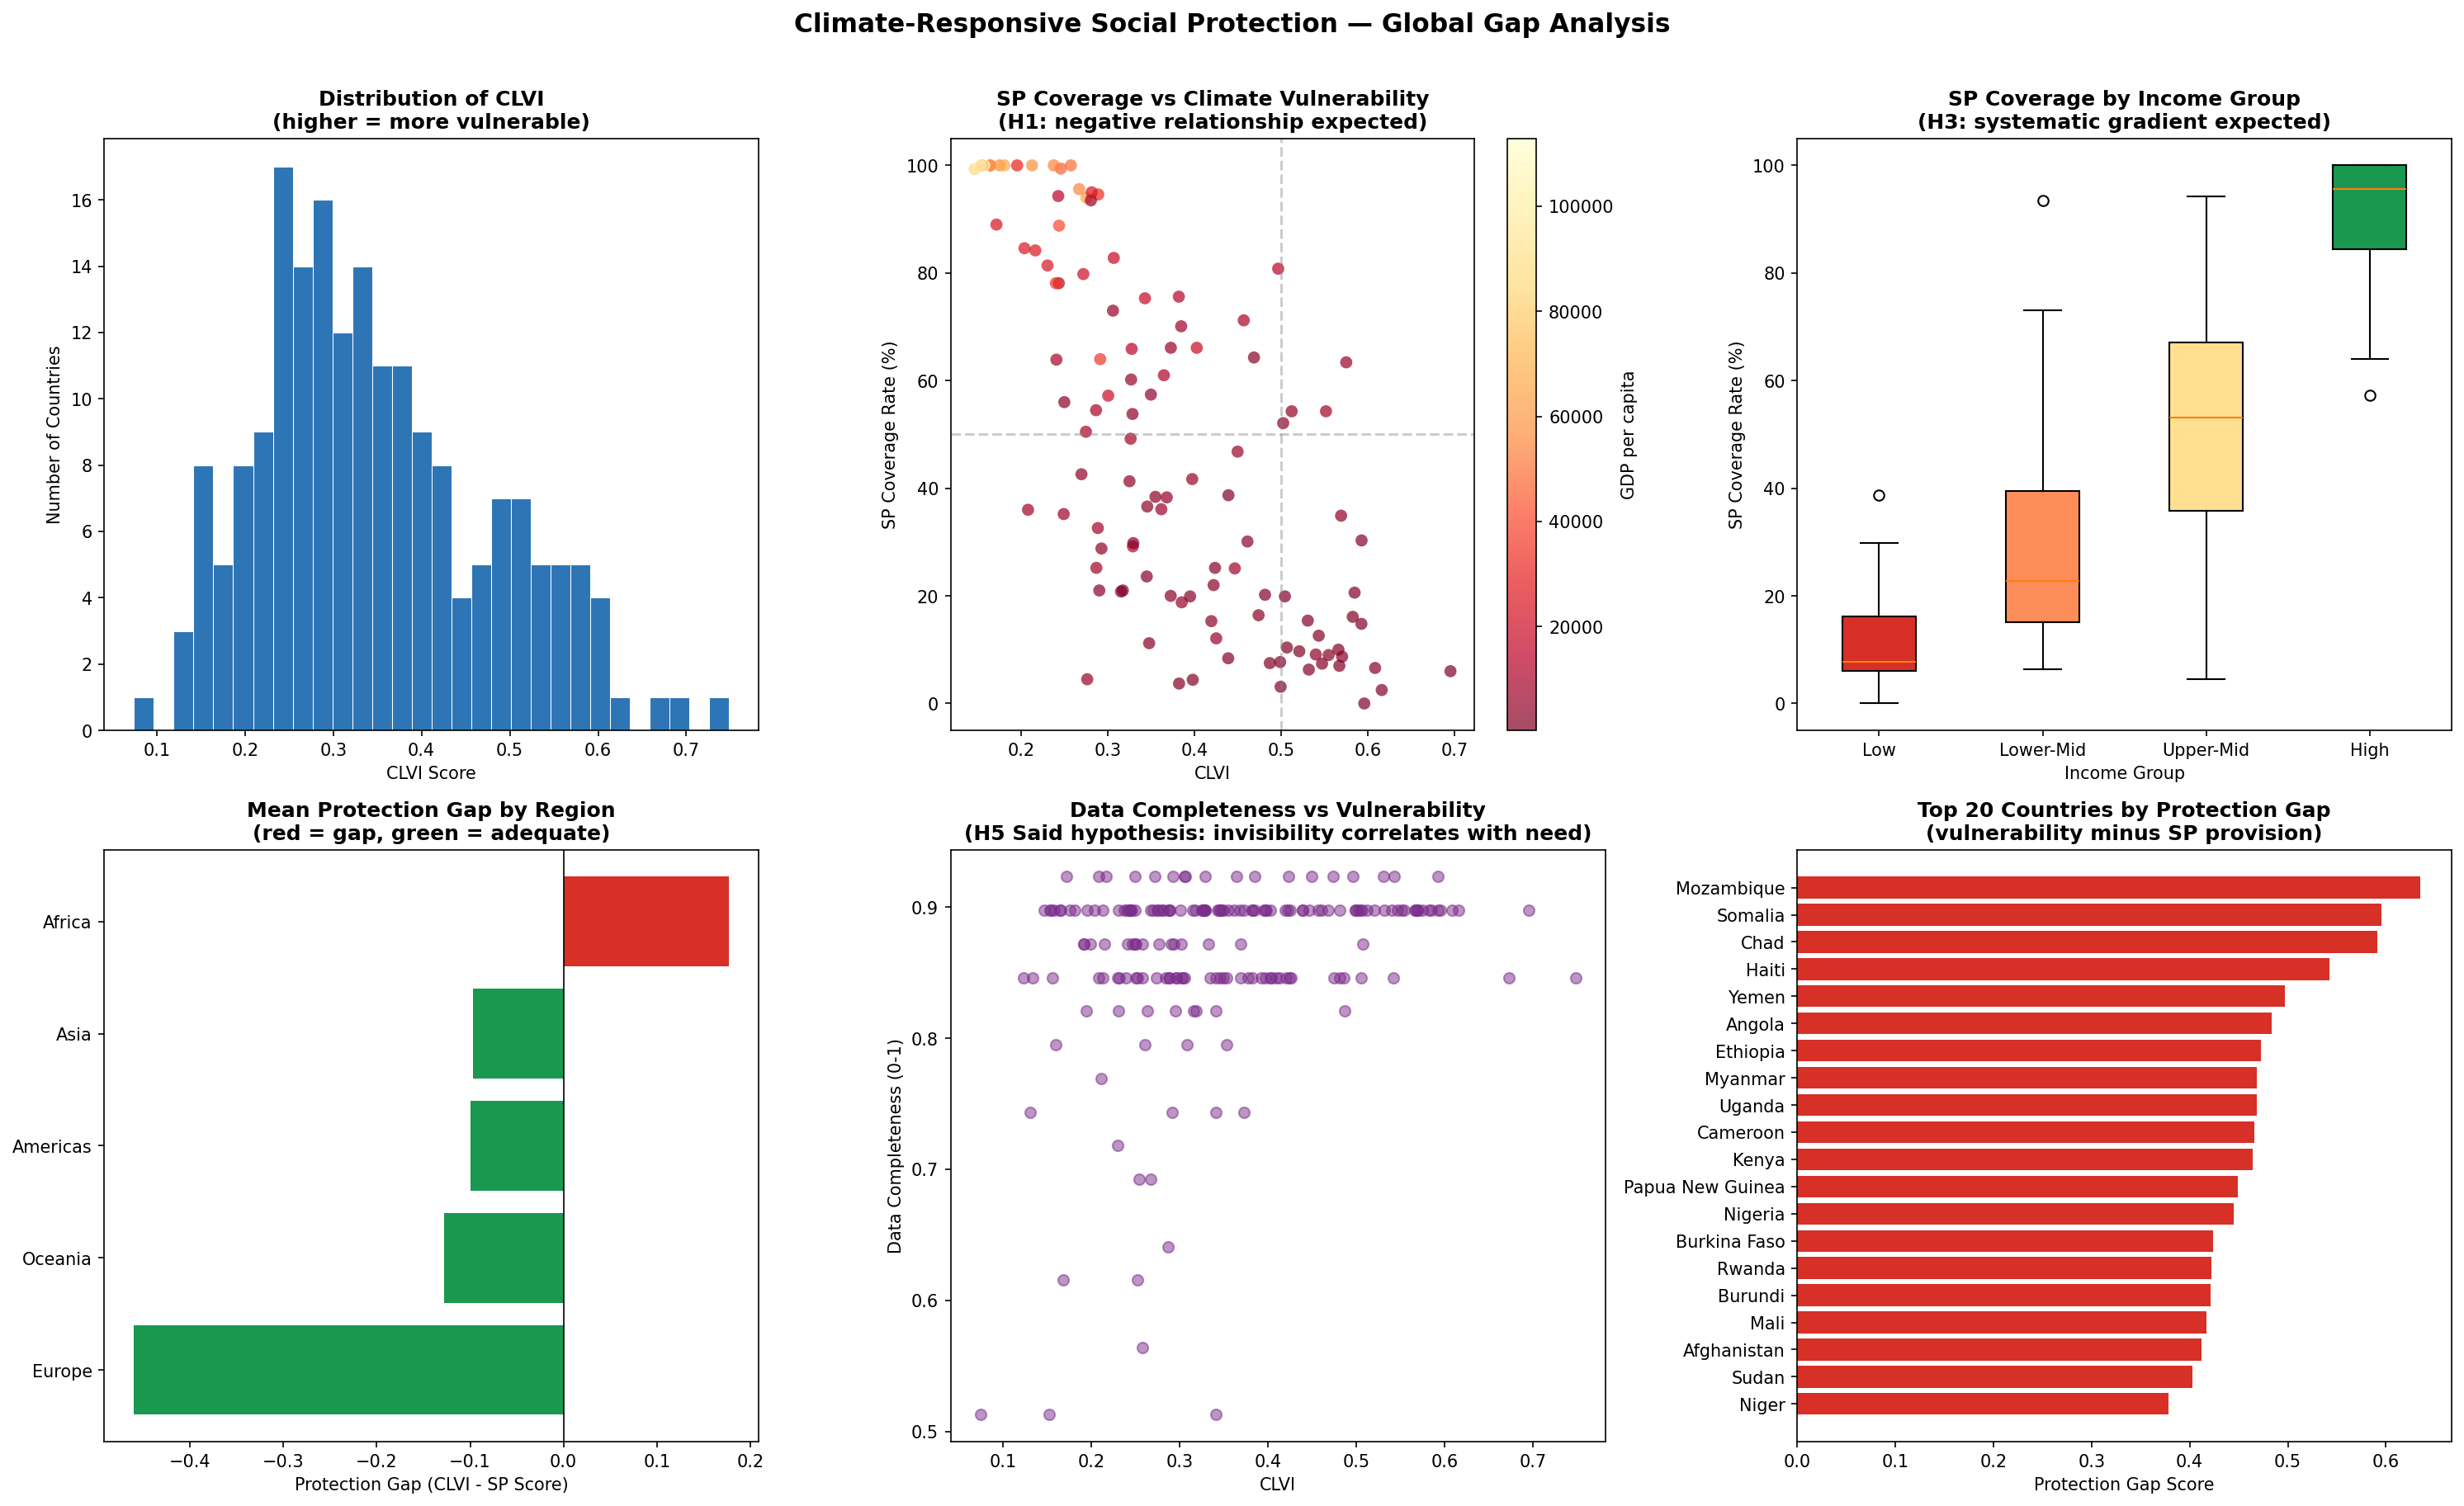

✓ Saved to outputs/analysis_panel.png


In [4]:
#Cell 4 — Visualisations
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Climate-Responsive Social Protection — Global Gap Analysis',
             fontsize=15, fontweight='bold', y=1.01)

# 1 — CLVI distribution
axes[0,0].hist(master['CLVI'].dropna(), bins=30,
               color='#2E75B6', edgecolor='white', linewidth=0.5)
axes[0,0].set_title('Distribution of CLVI\n(higher = more vulnerable)',
                     fontweight='bold')
axes[0,0].set_xlabel('CLVI Score')
axes[0,0].set_ylabel('Number of Countries')

# 2 — SP coverage vs CLVI scatter
sc = axes[0,1].scatter(
    master['CLVI'], master['sp_coverage_rate'],
    c=master['gdp_per_capita'], cmap='YlOrRd_r',
    alpha=0.7, s=50, edgecolors='none'
)
plt.colorbar(sc, ax=axes[0,1], label='GDP per capita')
axes[0,1].set_title('SP Coverage vs Climate Vulnerability\n(H1: negative relationship expected)',
                     fontweight='bold')
axes[0,1].set_xlabel('CLVI')
axes[0,1].set_ylabel('SP Coverage Rate (%)')
axes[0,1].axhline(50, color='grey', linestyle='--', alpha=0.4)
axes[0,1].axvline(0.5, color='grey', linestyle='--', alpha=0.4)

# 3 — SP coverage by income group
order = ['Low income','Lower middle income',
         'Upper middle income','High income']
income_data = [master[master['income_group']==g]['sp_coverage_rate'].dropna()
               for g in order]
bp = axes[0,2].boxplot(income_data, patch_artist=True,
                        labels=['Low','Lower-Mid','Upper-Mid','High'])
colors = ['#d73027','#fc8d59','#fee090','#1a9850']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[0,2].set_title('SP Coverage by Income Group\n(H3: systematic gradient expected)',
                     fontweight='bold')
axes[0,2].set_ylabel('SP Coverage Rate (%)')
axes[0,2].set_xlabel('Income Group')

# 4 — Protection gap by region
region_gap = (master.groupby('region_un')['protection_gap']
              .mean().sort_values(ascending=True).dropna())
colors_bar = ['#d73027' if v > 0 else '#1a9850' for v in region_gap]
axes[1,0].barh(region_gap.index, region_gap.values, color=colors_bar)
axes[1,0].axvline(0, color='black', linewidth=0.8)
axes[1,0].set_title('Mean Protection Gap by Region\n(red = gap, green = adequate)',
                     fontweight='bold')
axes[1,0].set_xlabel('Protection Gap (CLVI - SP Score)')

# 5 — Data completeness vs vulnerability
axes[1,1].scatter(master['CLVI'], master['data_completeness'],
                  alpha=0.5, color='#7B2D8B', s=40)
axes[1,1].set_title('Data Completeness vs Vulnerability\n(H5 Said hypothesis: invisibility correlates with need)',
                     fontweight='bold')
axes[1,1].set_xlabel('CLVI')
axes[1,1].set_ylabel('Data Completeness (0-1)')

# 6 — Top 20 red zone countries
top20 = (master[master['sp_coverage_rate'].notna()]
         .nlargest(20, 'protection_gap'))
colors_top = ['#d73027' if g > 0.3 else '#fc8d59'
              for g in top20['protection_gap']]
axes[1,2].barh(top20['country'], top20['protection_gap'],
               color=colors_top)
axes[1,2].invert_yaxis()
axes[1,2].set_title('Top 20 Countries by Protection Gap\n(vulnerability minus SP provision)',
                     fontweight='bold')
axes[1,2].set_xlabel('Protection Gap Score')

plt.tight_layout()
plt.savefig('outputs/analysis_panel.png', dpi=200, bbox_inches='tight')
plt.show()
print("✓ Saved to outputs/analysis_panel.png")

In [10]:
world = gpd.read_file('data/raw/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')

print(f"World: {world.shape}")
# Find the ISO3 column name
iso_cols = [c for c in world.columns if 'ISO' in c.upper() or 'ADM0' in c.upper()]
print(f"ISO columns: {iso_cols}")

World: (177, 169)
ISO columns: ['ADM0_DIF', 'ADM0_A3', 'NOTE_ADM0', 'ISO_A2', 'ISO_A2_EH', 'ISO_A3', 'ISO_A3_EH', 'ISO_N3', 'ISO_N3_EH', 'ADM0_ISO', 'ADM0_DIFF', 'ADM0_TLC', 'ADM0_A3_US', 'ADM0_A3_FR', 'ADM0_A3_RU', 'ADM0_A3_ES', 'ADM0_A3_CN', 'ADM0_A3_TW', 'ADM0_A3_IN', 'ADM0_A3_NP', 'ADM0_A3_PK', 'ADM0_A3_DE', 'ADM0_A3_GB', 'ADM0_A3_BR', 'ADM0_A3_IL', 'ADM0_A3_PS', 'ADM0_A3_SA', 'ADM0_A3_EG', 'ADM0_A3_MA', 'ADM0_A3_PT', 'ADM0_A3_AR', 'ADM0_A3_JP', 'ADM0_A3_KO', 'ADM0_A3_VN', 'ADM0_A3_TR', 'ADM0_A3_ID', 'ADM0_A3_PL', 'ADM0_A3_GR', 'ADM0_A3_IT', 'ADM0_A3_NL', 'ADM0_A3_SE', 'ADM0_A3_BD', 'ADM0_A3_UA', 'ADM0_A3_UN', 'ADM0_A3_WB', 'FCLASS_ISO']


Matched: 162 / 177 countries


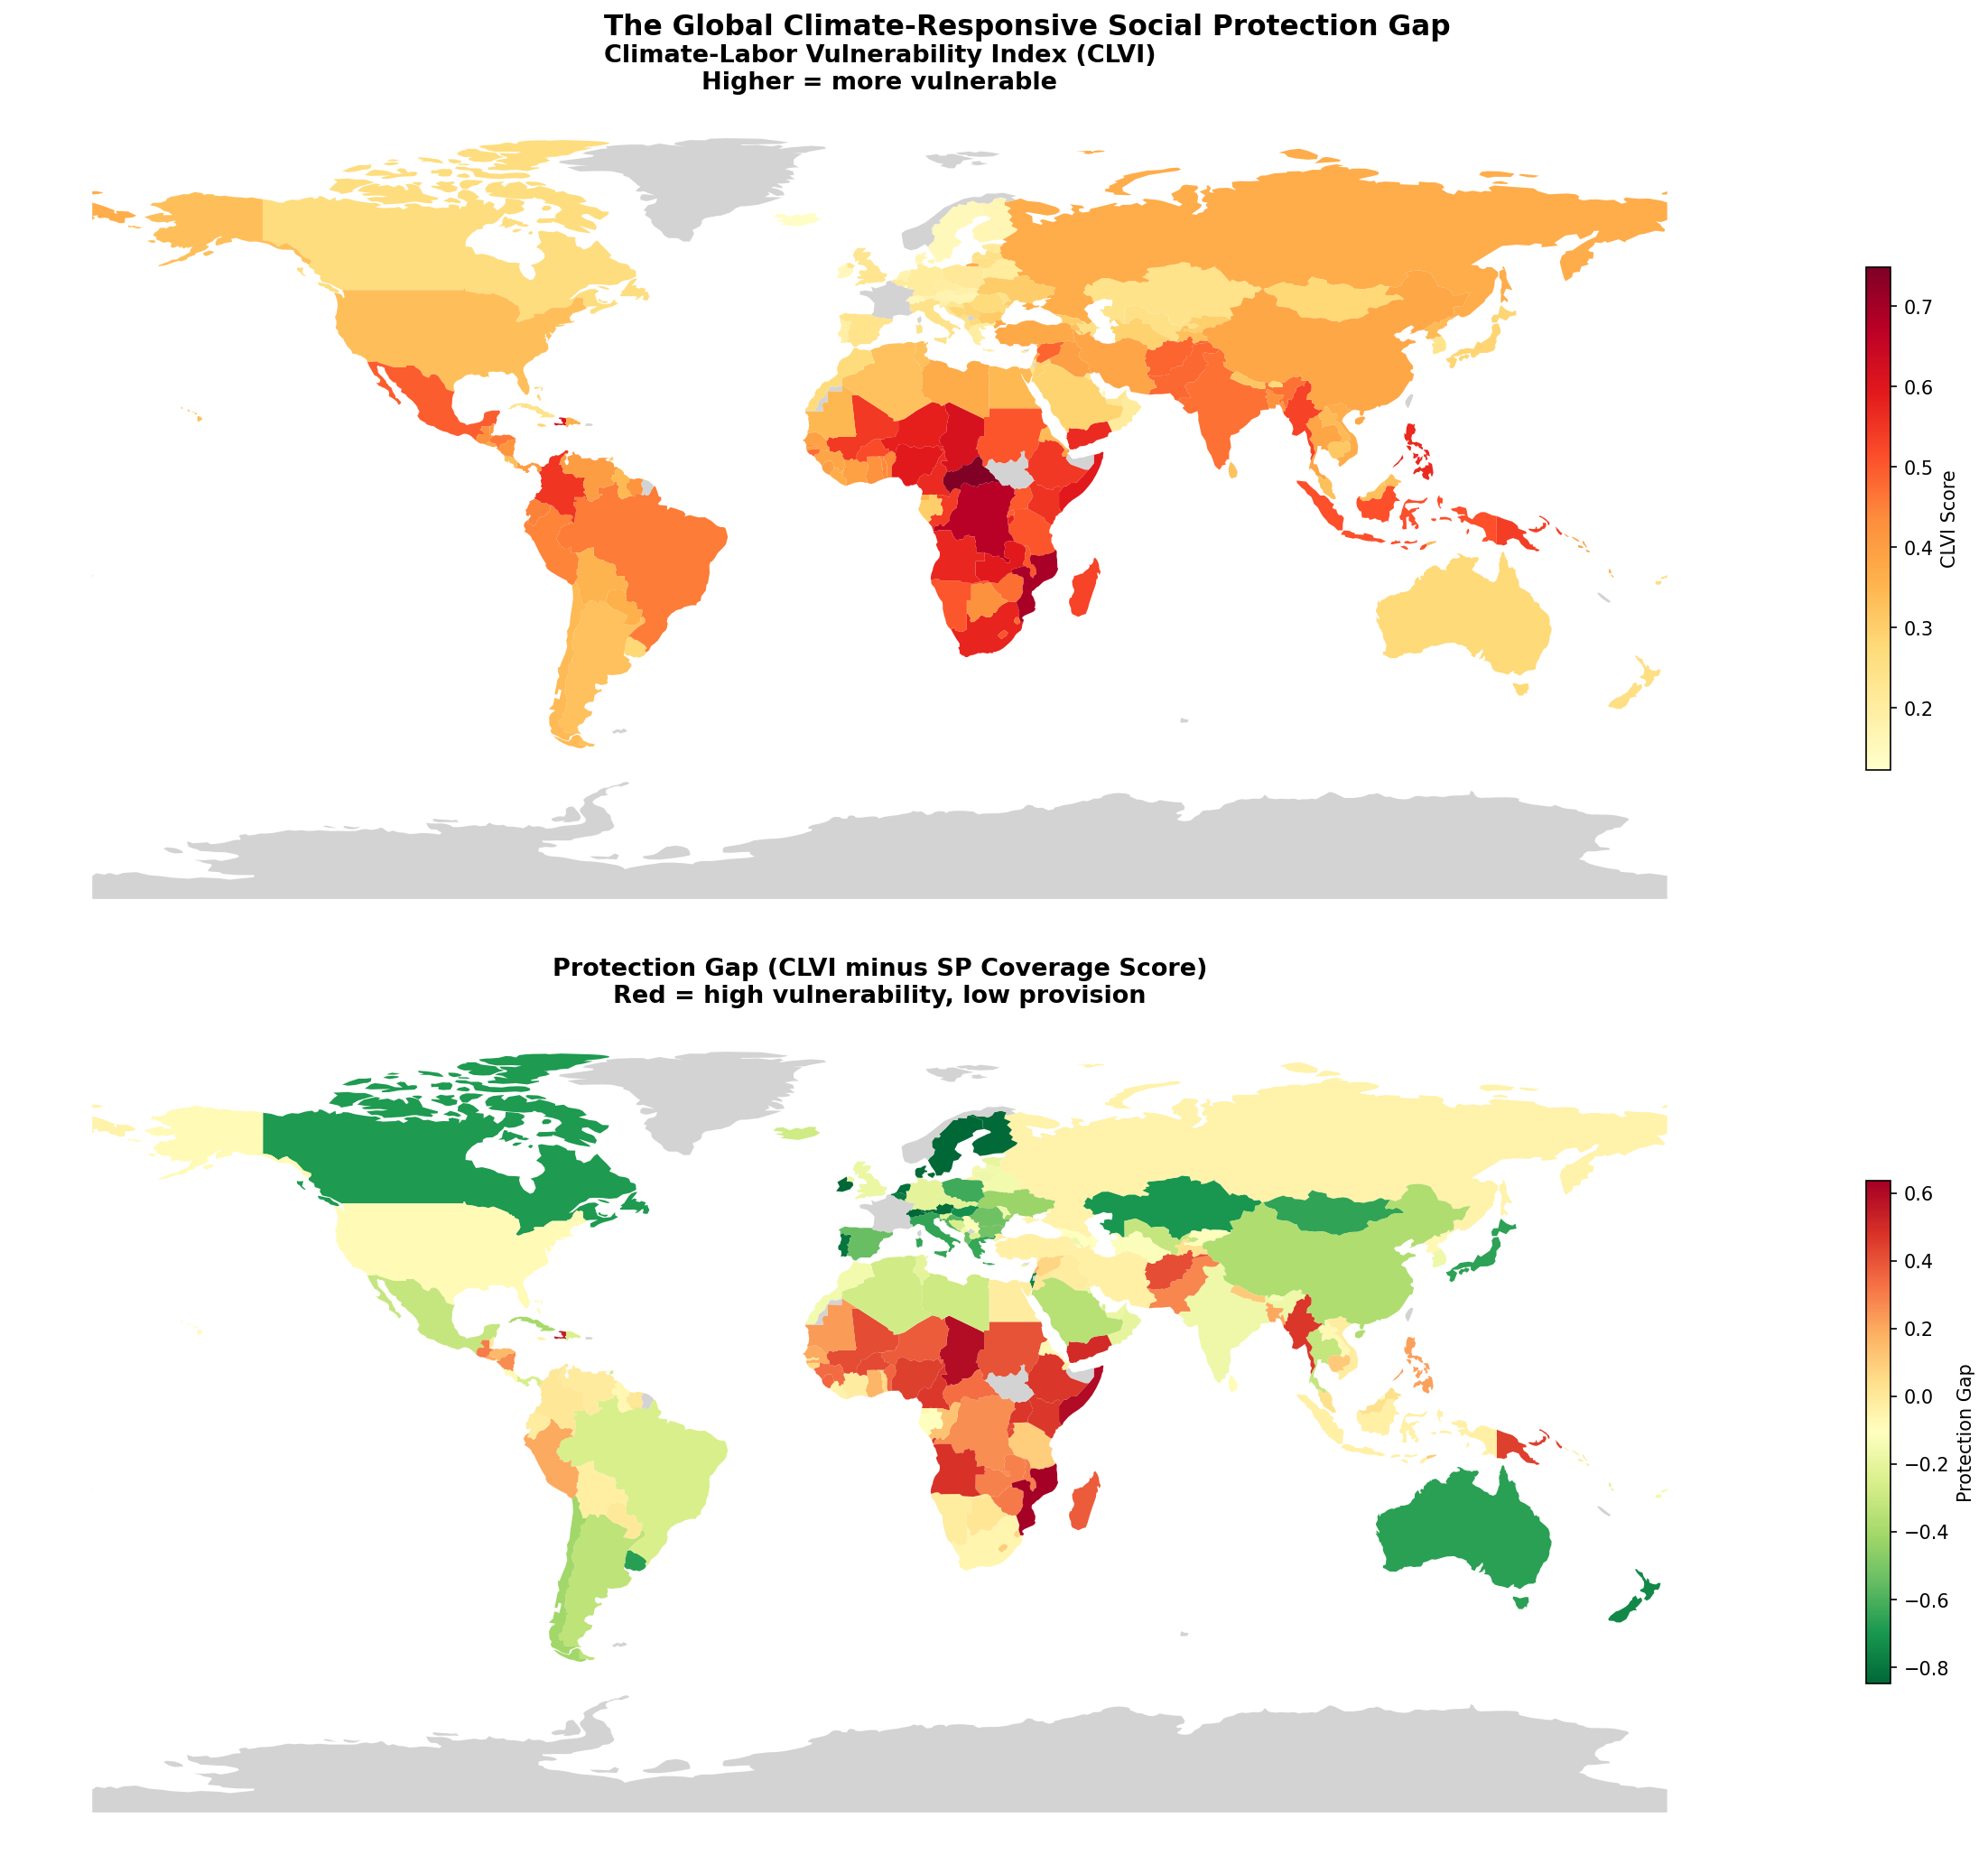

✓ Saved to outputs/world_maps.png


In [ ]:
#cell 5: world map
fig, axes = plt.subplots(2, 1, figsize=(18, 14))

# Merge master data onto world shapefile
world_plot = world.merge(
    master[['iso3','CLVI','sp_score','protection_gap','sp_coverage_rate']],
    left_on='ISO_A3', right_on='iso3', how='left'
)

print(f"Matched: {world_plot['CLVI'].notna().sum()} / {len(world_plot)} countries")

# Map 1 — CLVI
world_plot.plot(
    column='CLVI', cmap='YlOrRd', legend=True, ax=axes[0],
    missing_kwds={'color': 'lightgrey', 'label': 'No data'},
    legend_kwds={'label': 'CLVI Score', 'shrink': 0.6}
)
axes[0].set_title(
    'Climate-Labor Vulnerability Index (CLVI)\nHigher = more vulnerable',
    fontsize=13, fontweight='bold'
)
axes[0].axis('off')

# Map 2 — Protection Gap
world_plot.plot(
    column='protection_gap', cmap='RdYlGn_r', legend=True, ax=axes[1],
    missing_kwds={'color': 'lightgrey', 'label': 'No data'},
    legend_kwds={'label': 'Protection Gap', 'shrink': 0.6}
)
axes[1].set_title(
    'Protection Gap (CLVI minus SP Coverage Score)\n'
    'Red = high vulnerability, low provision',
    fontsize=13, fontweight='bold'
)
axes[1].axis('off')

plt.suptitle('The Global Climate-Responsive Social Protection Gap',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/world_maps.png', dpi=200, bbox_inches='tight')
plt.show()
print("✓ Saved to outputs/world_maps.png")

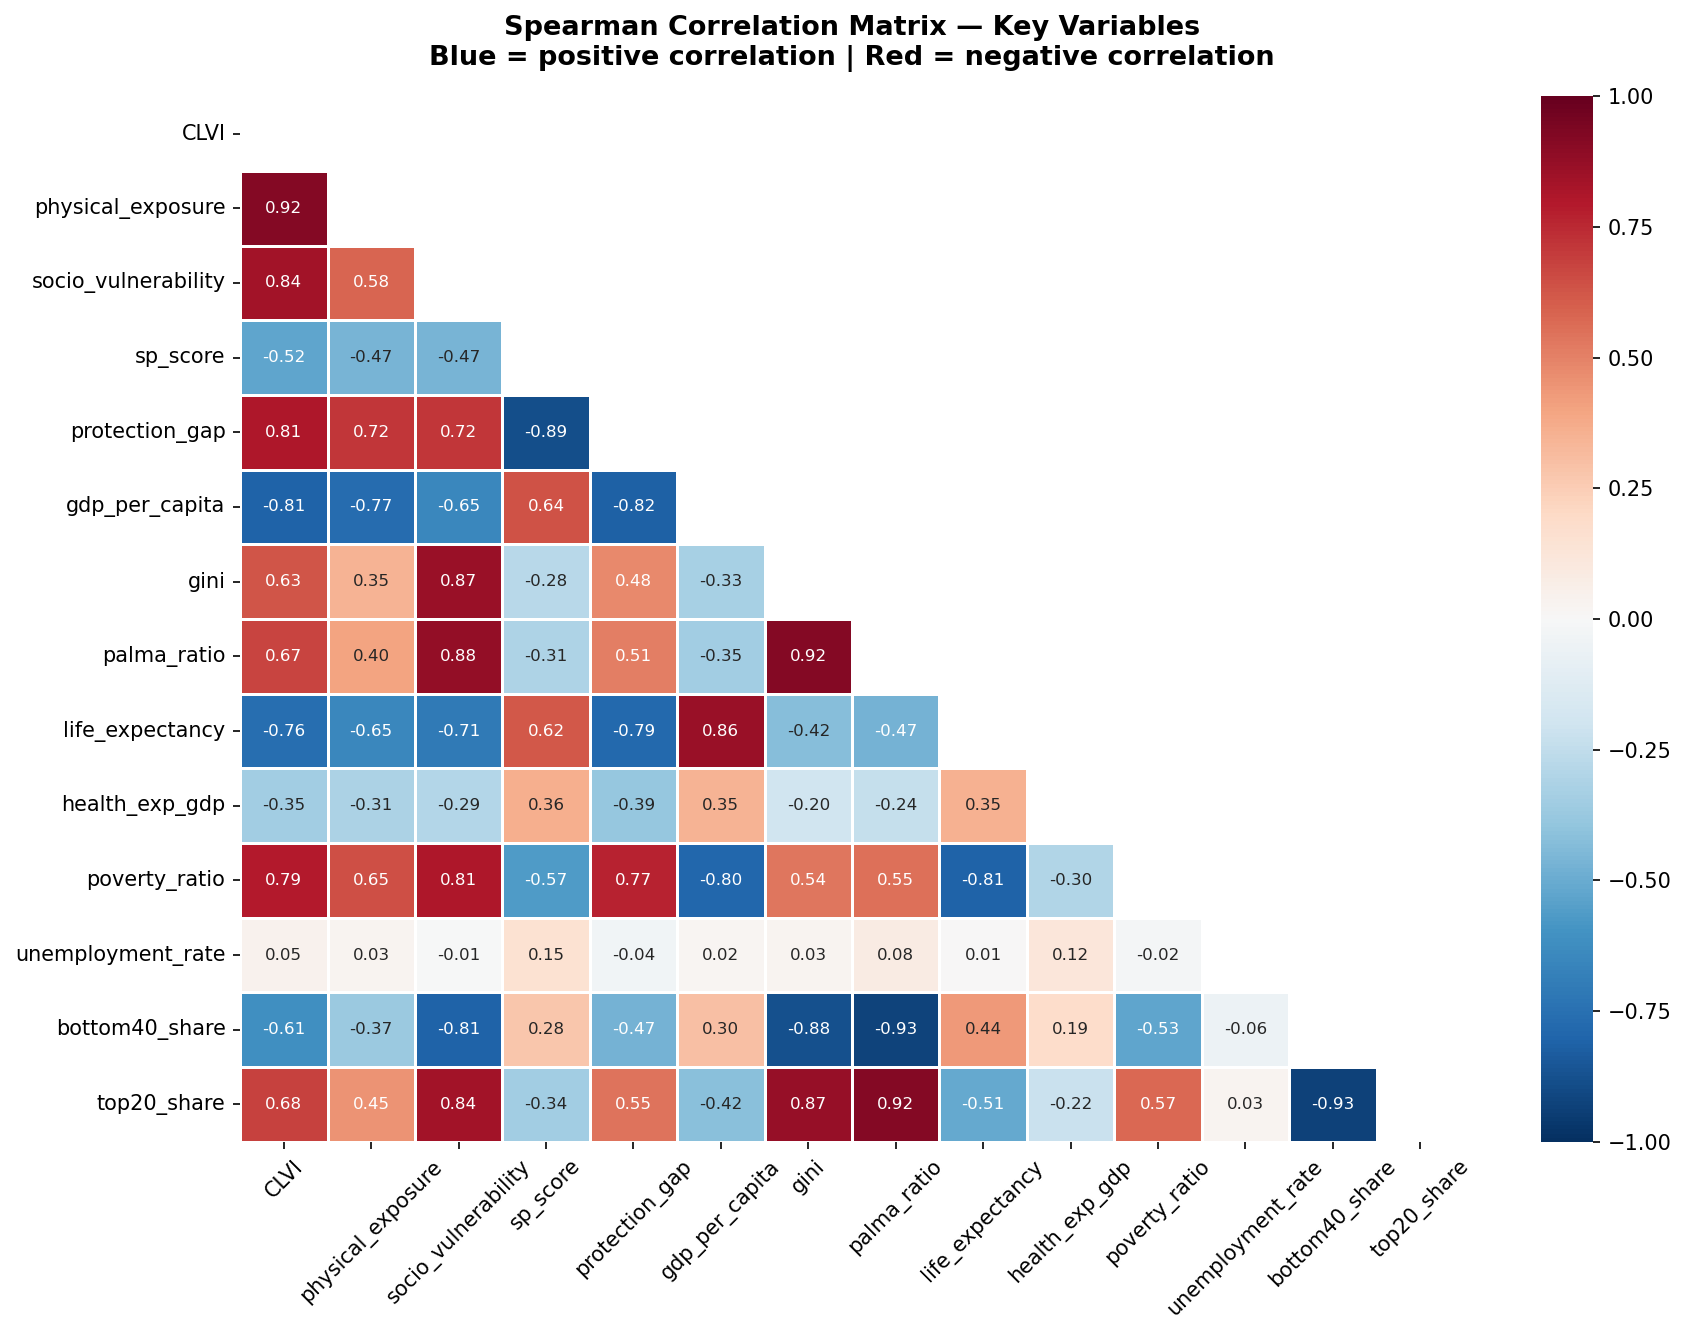

✓ Saved to outputs/correlation_heatmap.png


In [12]:
#Cell 6 — Correlation Heatmap
fig, ax = plt.subplots(figsize=(12, 9))

# Select the most meaningful variables for the heatmap
corr_vars = [
    'CLVI', 'physical_exposure', 'socio_vulnerability',
    'sp_score', 'protection_gap',
    'gdp_per_capita', 'gini', 'palma_ratio',
    'life_expectancy', 'health_exp_gdp',
    'poverty_ratio', 'unemployment_rate',
    'bottom40_share', 'top20_share'
]

# Keep only columns that exist and have enough data
available = [v for v in corr_vars
             if v in master.columns and master[v].notna().sum() > 30]

corr_matrix = master[available].corr(method='spearman')

# Generate mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 8},
    ax=ax
)

ax.set_title(
    'Spearman Correlation Matrix — Key Variables\n'
    'Blue = positive correlation | Red = negative correlation',
    fontsize=13, fontweight='bold', pad=15
)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print("✓ Saved to outputs/correlation_heatmap.png")

CLVI outliers (|z| > 2): 6
                         country     CLVI  clvi_zscore
        Central African Republic 0.748267     3.098191
                      Mozambique 0.695245     2.689049
Congo, the Democratic Republic o 0.672883     2.516494
                            Chad 0.615931     2.077029
                           Haiti 0.608290     2.018063
                          Monaco 0.074224    -2.103020

Protection gap outliers (IQR method): 12
    country     CLVI  sp_score  protection_gap
 Mozambique 0.695245     0.060        0.635245
    Somalia 0.595780     0.000        0.595780
    Belgium 0.212491     1.000       -0.787509
   Portugal 0.195253     1.000       -0.804747
Netherlands 0.180614     1.000       -0.819386
    Austria 0.175019     1.000       -0.824981
    Denmark 0.164764     1.000       -0.835236
    Finland 0.163804     1.000       -0.836196
    Ireland 0.157211     1.000       -0.842789
     Sweden 0.154338     1.000       -0.845662
Switzerland 0.153376     1.00

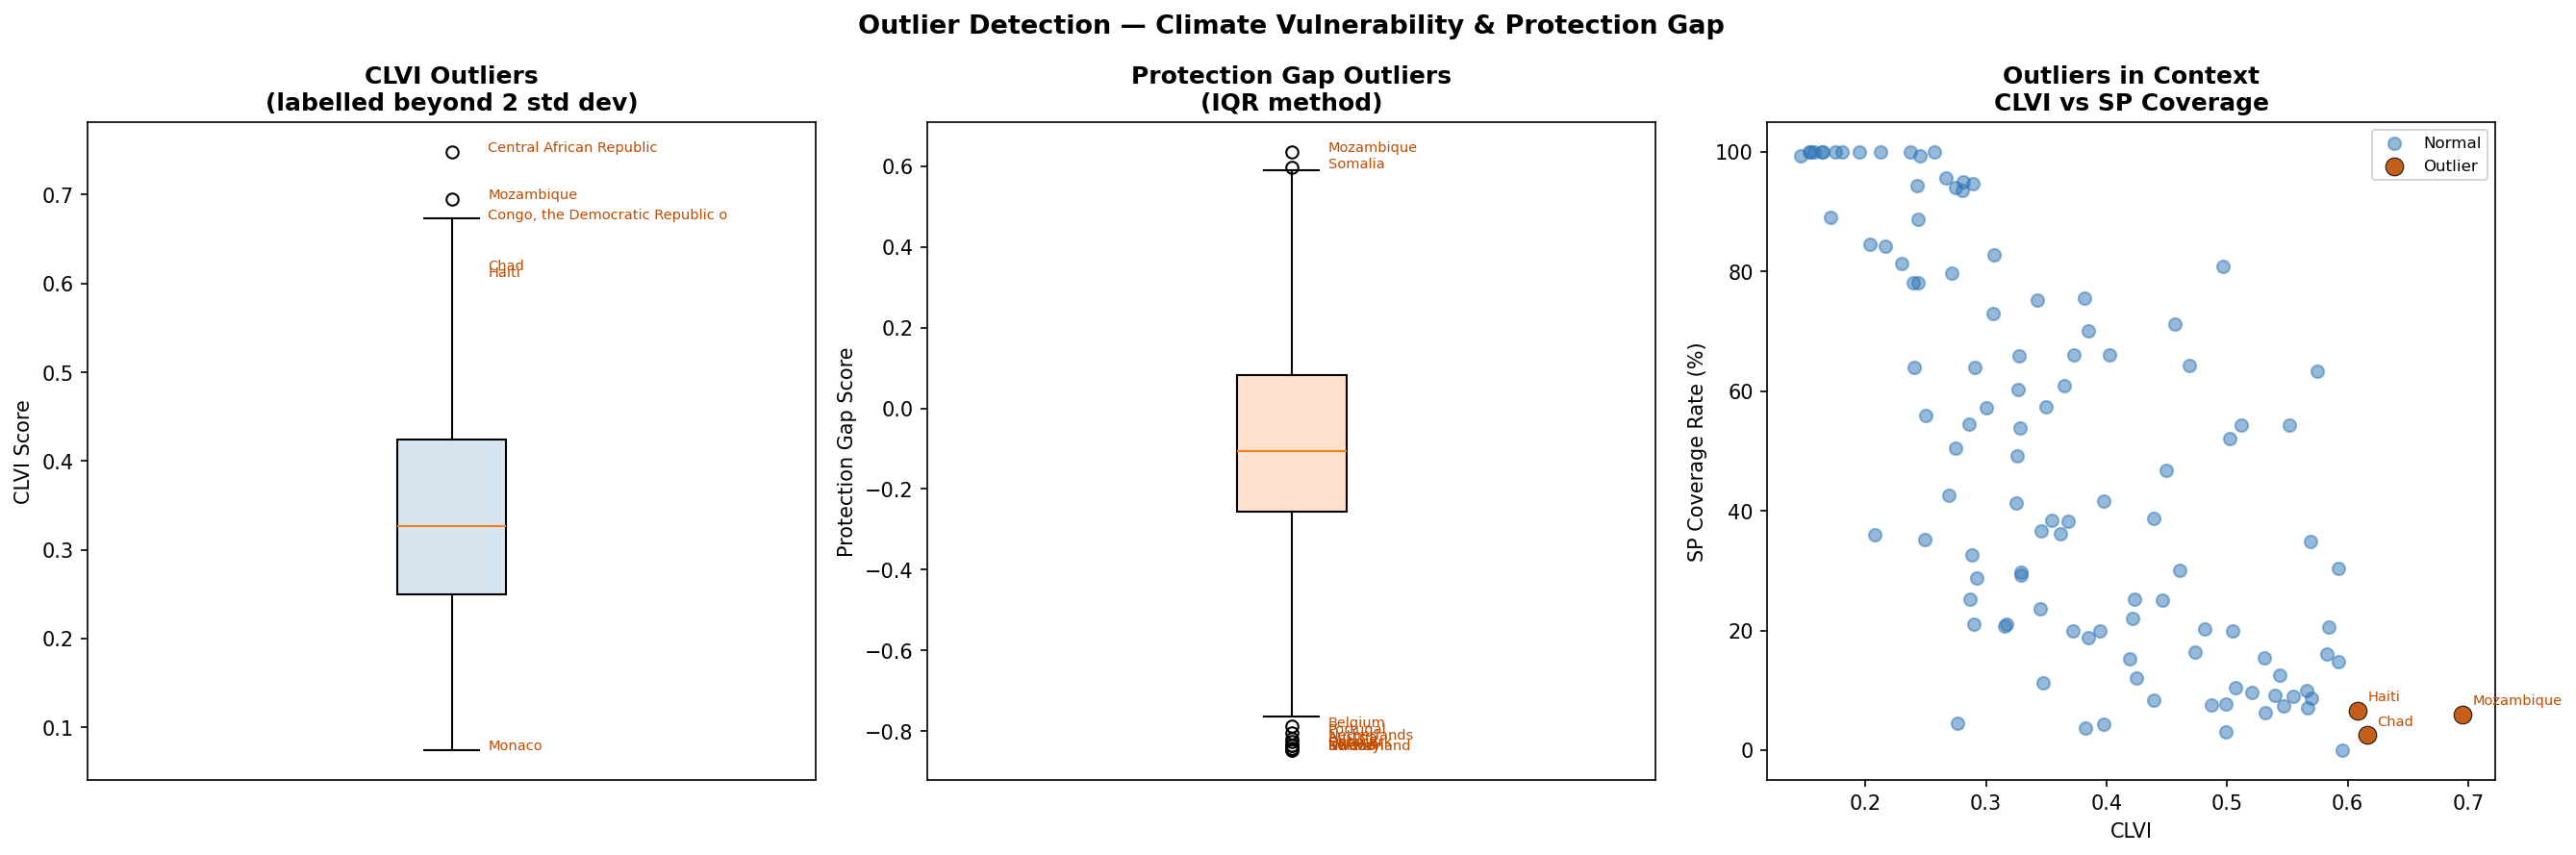

✓ Saved to outputs/outlier_detection.png


In [13]:
#Cell 7 — Outlier Detection
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Method 1: Z-score outliers on CLVI ───────────────────────────────────────
from scipy.stats import zscore

master['clvi_zscore'] = zscore(master['CLVI'].fillna(master['CLVI'].mean()))
master['sp_zscore']   = zscore(master['sp_score'].fillna(master['sp_score'].mean()))

outliers_clvi = master[master['clvi_zscore'].abs() > 2].copy()
print(f"CLVI outliers (|z| > 2): {len(outliers_clvi)}")
print(outliers_clvi[['country','CLVI','clvi_zscore']].sort_values(
    'clvi_zscore', ascending=False).to_string(index=False))

# ── Method 2: IQR outliers on protection gap ─────────────────────────────────
Q1 = master['protection_gap'].quantile(0.25)
Q3 = master['protection_gap'].quantile(0.75)
IQR = Q3 - Q1
outliers_gap = master[
    (master['protection_gap'] < Q1 - 1.5 * IQR) |
    (master['protection_gap'] > Q3 + 1.5 * IQR)
].copy()
print(f"\nProtection gap outliers (IQR method): {len(outliers_gap)}")
print(outliers_gap[['country','CLVI','sp_score','protection_gap']]
      .sort_values('protection_gap', ascending=False).to_string(index=False))

# ── Plot 1: CLVI boxplot with outliers labelled ───────────────────────────────
axes[0].boxplot(master['CLVI'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='#D6E4F0'))
for _, row in outliers_clvi.iterrows():
    axes[0].annotate(row['country'],
                     xy=(1, row['CLVI']),
                     xytext=(1.05, row['CLVI']),
                     fontsize=7, color='#BF4C00')
axes[0].set_title('CLVI Outliers\n(labelled beyond 2 std dev)',
                   fontweight='bold')
axes[0].set_ylabel('CLVI Score')
axes[0].set_xticks([])

# ── Plot 2: Protection gap boxplot ───────────────────────────────────────────
axes[1].boxplot(master['protection_gap'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='#FFE0CC'))
for _, row in outliers_gap.iterrows():
    axes[1].annotate(row['country'],
                     xy=(1, row['protection_gap']),
                     xytext=(1.05, row['protection_gap']),
                     fontsize=7, color='#BF4C00')
axes[1].set_title('Protection Gap Outliers\n(IQR method)',
                   fontweight='bold')
axes[1].set_ylabel('Protection Gap Score')
axes[1].set_xticks([])

# ── Plot 3: Scatter with outliers highlighted ─────────────────────────────────
normal    = master[master['clvi_zscore'].abs() <= 2]
outlier   = master[master['clvi_zscore'].abs() > 2]

axes[2].scatter(normal['CLVI'], normal['sp_coverage_rate'],
                alpha=0.5, color='#2E75B6', s=40, label='Normal')
axes[2].scatter(outlier['CLVI'], outlier['sp_coverage_rate'],
                alpha=0.9, color='#BF4C00', s=80,
                edgecolors='black', linewidth=0.5, label='Outlier')

for _, row in outlier.iterrows():
    if pd.notna(row['sp_coverage_rate']):
        axes[2].annotate(row['country'],
                         xy=(row['CLVI'], row['sp_coverage_rate']),
                         xytext=(5, 5), textcoords='offset points',
                         fontsize=7, color='#BF4C00')

axes[2].set_title('Outliers in Context\nCLVI vs SP Coverage',
                   fontweight='bold')
axes[2].set_xlabel('CLVI')
axes[2].set_ylabel('SP Coverage Rate (%)')
axes[2].legend(fontsize=8)

plt.suptitle('Outlier Detection — Climate Vulnerability & Protection Gap',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/outlier_detection.png', dpi=200, bbox_inches='tight')
plt.show()
print("✓ Saved to outputs/outlier_detection.png")

In [ ]:
"""CLVI outliers — the extreme vulnerability end:
Central African Republic, Mozambique, DRC, Chad, Haiti are genuine red-zone countries — extremely high physical exposure combined with deep 
socioeconomic precarity. Monaco at the other end is a statistical curiosity (tiny, wealthy microstate) and worth noting as a data quirk rather 
than a meaningful finding.Protection gap outliers — two very different stories:
The negative outliers (Belgium, Norway, Sweden etc.) are not problems — they are the benchmark. These countries have SP coverage so 
comprehensive it exceeds their already-low vulnerability score, producing a large negative gap. That's the target every other country 
should be moving toward.Mozambique and Somalia at the top are the crisis cases — Mozambique has a CLVI of 0.70 but SP score of only 0.06. 
Somalia has zero measurable SP coverage at all. These two alone make the Sen capabilities argument viscerally clear."""

In [14]:
#Cell 8 — Quadrant Chart (Plotly Interactive)
import plotly.express as px
import plotly.graph_objects as go

plot_data = master[master['sp_coverage_rate'].notna()].copy()

# Quadrant labels
def quadrant(row):
    if row['CLVI'] >= 0.5 and row['sp_score'] < 0.5:
        return 'Red Zone — High need, low protection'
    elif row['CLVI'] >= 0.5 and row['sp_score'] >= 0.5:
        return 'Tension Zone — High need, some protection'
    elif row['CLVI'] < 0.5 and row['sp_score'] < 0.5:
        return 'Gap Zone — Lower need, still underprotected'
    else:
        return 'Safe Zone — Low need, high protection'

plot_data['quadrant'] = plot_data.apply(quadrant, axis=1)

color_map = {
    'Red Zone — High need, low protection':       '#d73027',
    'Tension Zone — High need, some protection':  '#fc8d59',
    'Gap Zone — Lower need, still underprotected':'#fee090',
    'Safe Zone — Low need, high protection':      '#1a9850',
}

fig = px.scatter(
    plot_data,
    x='CLVI',
    y='sp_coverage_rate',
    color='quadrant',
    color_discrete_map=color_map,
    hover_name='country',
    hover_data={
        'CLVI': ':.3f',
        'sp_coverage_rate': ':.1f',
        'gdp_per_capita': ':,.0f',
        'gini': ':.1f',
        'income_group': True,
        'region_un': True,
        'quadrant': False,
    },
    size_max=20,
    title=(
        'Capability Gap: Climate Vulnerability vs Social Protection Coverage<br>'
        '<sup>Each dot = one country | '
        'Bottom-right = highest unmet need | '
        'Inspired by Sen (1999)</sup>'
    ),
    labels={
        'CLVI': 'Climate-Labor Vulnerability Index (CLVI) →',
        'sp_coverage_rate': 'SP Coverage Rate (%) →',
    }
)

# Quadrant reference lines
fig.add_hline(y=50, line_dash='dash', line_color='grey',
              opacity=0.5, line_width=1)
fig.add_vline(x=0.5, line_dash='dash', line_color='grey',
              opacity=0.5, line_width=1)

# Annotate key outlier countries
label_countries = ['Mozambique','Somalia','Haiti','Chad',
                   'Central African Republic','Norway','Sweden','Niger']
for _, row in plot_data[plot_data['country'].isin(label_countries)].iterrows():
    fig.add_annotation(
        x=row['CLVI'],
        y=row['sp_coverage_rate'],
        text=row['country'],
        showarrow=True,
        arrowhead=2,
        arrowsize=0.8,
        arrowwidth=1,
        arrowcolor='#555555',
        font=dict(size=10, color='#333333'),
        bgcolor='rgba(255,255,255,0.7)',
        bordercolor='#cccccc',
        borderwidth=1,
        ax=25, ay=-25
    )

# Quadrant labels
fig.add_annotation(x=0.75, y=8,  text='RED ZONE',
                   showarrow=False,
                   font=dict(size=12, color='#d73027', family='Arial Black'),
                   bgcolor='rgba(255,235,235,0.6)')
fig.add_annotation(x=0.12, y=95, text='SAFE ZONE',
                   showarrow=False,
                   font=dict(size=12, color='#1a9850', family='Arial Black'),
                   bgcolor='rgba(235,255,235,0.6)')

fig.update_traces(marker=dict(size=9, opacity=0.8,
                               line=dict(width=0.5, color='white')))
fig.update_layout(
    height=620,
    font=dict(family='Arial', size=11),
    legend=dict(
        title='Quadrant',
        orientation='h',
        yanchor='bottom', y=1.02,
        xanchor='right', x=1
    ),
    plot_bgcolor='#FAFAFA',
    paper_bgcolor='white',
)

fig.write_html('outputs/quadrant_scatter.html')
fig.show()
print("✓ Saved to outputs/quadrant_scatter.html")
print(f"\nQuadrant counts:")
print(plot_data['quadrant'].value_counts())

✓ Saved to outputs/quadrant_scatter.html

Quadrant counts:
quadrant
Safe Zone — Low need, high protection          48
Gap Zone — Lower need, still underprotected    40
Red Zone — High need, low protection           21
Tension Zone — High need, some protection       4
Name: count, dtype: int64


In [ ]:
"""113 countries have SP coverage data. Of those:
21 countries (19%) are in the Red Zone — highest climate vulnerability, lowest protection. 
These are the people Sen would say have had their capabilities stripped twice over: once by climate exposure, once by state abandonment.
4 countries (4%) are in the Tension Zone — high vulnerability but some protection exists. 
These are the fragile middle cases where systems exist but are under strain.
40 countries (35%) are in the Gap Zone — lower physical vulnerability but still underprotected. 
Mostly lower-middle income countries where informality is high but climate risk is moderate.
48 countries (42%) are in the Safe Zone — this is almost entirely the Global North.
The ratio that matters for your report: of the 25 countries with any meaningful vulnerability (CLVI > 0.5), 21 of them (84%) have 
inadequate protection. That is H1 confirmed in a single number.Also worth noting: 79 countries have no SP coverage data at all — 
those are the H5 invisible countries. 
The real red zone is almost certainly larger than 21."""

In [15]:
#Cell 9 — Summary Statistics Table for Report
# ── Clean summary table for each quadrant ────────────────────────────────────
plot_data = master[master['sp_coverage_rate'].notna()].copy()

def quadrant(row):
    if row['CLVI'] >= 0.5 and row['sp_score'] < 0.5:
        return 'Red Zone'
    elif row['CLVI'] >= 0.5 and row['sp_score'] >= 0.5:
        return 'Tension Zone'
    elif row['CLVI'] < 0.5 and row['sp_score'] < 0.5:
        return 'Gap Zone'
    else:
        return 'Safe Zone'

plot_data['quadrant'] = plot_data.apply(quadrant, axis=1)

summary = plot_data.groupby('quadrant').agg(
    n_countries        = ('country',          'count'),
    mean_clvi          = ('CLVI',             'mean'),
    mean_sp_coverage   = ('sp_coverage_rate', 'mean'),
    mean_gdp           = ('gdp_per_capita',   'mean'),
    mean_gini          = ('gini',             'mean'),
    mean_life_exp      = ('life_expectancy',  'mean'),
    mean_health_exp    = ('health_exp_gdp',   'mean'),
).round(2)

# Reorder rows meaningfully
order = ['Red Zone','Tension Zone','Gap Zone','Safe Zone']
summary = summary.reindex(order)
print("Quadrant Summary Statistics:")
print(summary.to_string())

# ── Countries in the Red Zone ─────────────────────────────────────────────────
print("\n\nRed Zone Countries (H1 confirmed cases):")
red = (plot_data[plot_data['quadrant'] == 'Red Zone']
       .sort_values('protection_gap', ascending=False)
       [['country','region_un','income_group','CLVI',
         'sp_coverage_rate','gdp_per_capita','gini']]
       .round(3))
print(red.to_string(index=False))

# ── H5: invisible countries ───────────────────────────────────────────────────
invisible = master[master['sp_coverage_rate'].isna()]
print(f"\n\nH5 — Countries with no SP coverage data: {len(invisible)}")
print(f"Their mean CLVI: {invisible['CLVI'].mean():.3f}")
print(f"Visible countries mean CLVI: {master[master['sp_coverage_rate'].notna()]['CLVI'].mean():.3f}")

r_vis, p_vis = spearmanr(
    master['CLVI'].fillna(0),
    master['sp_coverage_rate'].isna().astype(int)
)
print(f"Spearman r (CLVI vs data invisibility): {r_vis:.3f}, p={p_vis:.4f}")
print("→", "✓ H5 Supported — more vulnerable = less data (Said)" 
      if r_vis > 0 and p_vis < 0.05 else "✗ H5 not supported")

Quadrant Summary Statistics:
              n_countries  mean_clvi  mean_sp_coverage  mean_gdp  mean_gini  mean_life_exp  mean_health_exp
quadrant                                                                                                   
Red Zone               21       0.57             12.25   1356.76      42.38          63.73             4.98
Tension Zone            4       0.54             56.02   5881.24      53.55          70.60             7.31
Gap Zone               40       0.37             24.71   4059.93      37.84          70.70             6.79
Safe Zone              48       0.27             81.24  30903.52      34.12          78.63             8.15


Red Zone Countries (H1 confirmed cases):
         country region_un        income_group  CLVI  sp_coverage_rate  gdp_per_capita  gini
      Mozambique    Africa          Low income 0.695               6.0         656.777 43.90
         Somalia    Africa          Low income 0.596               0.0         629.539 39.70
 